# Example workflow of tools in the OpenSense software ecosystem

In [1]:
import matplotlib.pyplot as plt

import poligrain as plg
import pypwsqc
import mergeplg
import pycomlink as pycml

/Users/chwala-c/miniforge3/envs/opensense_software_ecosystem_example/lib/python3.12/site-packages/pycomlink/io/examples.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Load open OpenMRG example data and project coordinates

We load 8 days of the OpenMRG dataset and do some quick visualization of the data using `poligrain`.

In [2]:
(
    ds_rad,
    ds_cmls,
    ds_gauges_municp,
    ds_gauge_smhi,
) = plg.example_data.load_openmrg(data_dir="example_data", subset="8d")

File already exists at example_data/openmrg_cml_8d.nc
Not downloading!
File already exists at example_data/openmrg_rad_8d.nc
Not downloading!
File already exists at example_data/openmrg_municp_gauge_8d.nc
Not downloading!
File already exists at example_data/openmrg_smhi_gauge_8d.nc
Not downloading!


In [3]:
# Project data to coordinate system
# UTM32N: https://epsg.io/32632
ref_str = "EPSG:32632"

# gauges
ds_gauges_municp.coords["x"], ds_gauges_municp.coords["y"] = plg.spatial.project_point_coordinates(
    ds_gauges_municp.lon, ds_gauges_municp.lat, ref_str
)

# CMLs
ds_cmls.coords["site_0_x"], ds_cmls.coords["site_0_y"] = plg.spatial.project_point_coordinates(
    ds_cmls.site_0_lon, ds_cmls.site_0_lat, ref_str
)
ds_cmls.coords["site_1_x"], ds_cmls.coords["site_1_y"] = plg.spatial.project_point_coordinates(
    ds_cmls.site_1_lon, ds_cmls.site_1_lat, ref_str
)

# Radar
ds_rad.coords["x_grid"], ds_rad.coords["y_grid"] = plg.spatial.project_point_coordinates(
    ds_rad.lon, ds_rad.lat, ref_str
)

<Axes: xlabel='lon', ylabel='lat'>

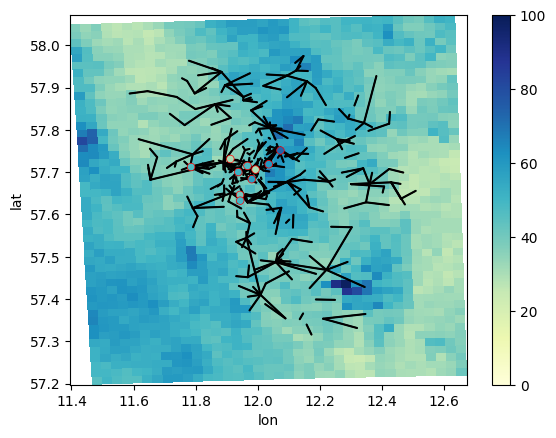

In [4]:
plg.plot_map.plot_plg(
    da_grid=ds_rad.R.resample(time='1h').mean().sum(dim="time"),
    da_gauges=ds_gauges_municp.rainfall_amount.sum(dim='time'),
    da_cmls=ds_cmls,
    vmin=0,
    vmax=100,
    cmap='YlGnBu',
    kwargs_cmls_plot={"line_color": "k", "line_width": 1},
    kwargs_gauges_plot={"edge_color": "r", "s": 30},
)

## CML processing

Here we do a standard CML processing with, what we believe, are reasonable methods and parameters. Note that, we use the radar as wet-dry indicator and we use `poligrain` to extract the path-averaged radar data for each CML which is needed for that.

In [5]:
ds_cmls['tl'] = ds_cmls.tsl - ds_cmls.rsl

# get radar along CMLs
grid_at_lines = plg.spatial.GridAtLines(
    da_gridded_data=ds_rad.R,
    ds_line_data=ds_cmls,
)
da_radar_along_cmls = grid_at_lines(ds_rad.R)

# wet-dry classification based on 
# smoothed radar rain rates along each CML
ds_cmls['wet'] = (
    (da_radar_along_cmls > 0.1)
    .rolling(time=6*3, center=True)
    .max()
)
ds_cmls['wet'] = ds_cmls.wet.ffill(dim='time')

#ds_cmls['wet'] = ds_cmls.tl.rolling(time=10*60).std() > 0.3

# calculate baseline
ds_cmls["baseline"] = pycml.processing.baseline.baseline_constant(
    trsl=ds_cmls.tl,
    wet=ds_cmls.wet,
    n_average_last_dry=5,
)

# calculate wet antenna effect
ds_cmls["A_obs"] = ds_cmls.tl - ds_cmls.baseline
ds_cmls["A_obs"] = ds_cmls.A_obs.where(ds_cmls.A_obs >= 0, 0)
ds_cmls["waa"] = pycml.processing.wet_antenna.waa_pastorek_2021_from_A_obs(
    A_obs=ds_cmls.A_obs,
    f_Hz=ds_cmls.frequency * 1e6,
    pol=ds_cmls.polarization.data,
    L_km=ds_cmls.length / 1000,
    A_max=6,
    zeta=0.7,
    d=0.15,
)

# calculate attenuation caused by rain and remove negative attenuation
ds_cmls["A"] = ds_cmls.tl - ds_cmls.baseline - ds_cmls.waa
ds_cmls["A"].data[ds_cmls.A < 0] = 0
# derive rain rate via the k-R relation
ds_cmls["R"] = pycml.processing.k_R_relation.calc_R_from_A(
    A=ds_cmls.A,
    L_km=ds_cmls.length.astype(float) / 1000,
    f_GHz=ds_cmls.frequency / 1000,
    pol=ds_cmls.polarization,
)
ds_cmls["R"].data[ds_cmls.R < 0.1] = 0

# Calcualte rainfall sums for plotting
rad_sum = ds_rad.R.resample(time='1h').mean().sum(dim='time')
cml_sum = ds_cmls.R.isel(sublink_id=0).resample(time='1h').mean().sum(dim='time', skipna=False)
rad_along_cml_sum = da_radar_along_cmls.resample(time='1h').mean().sum(dim='time')

<Axes: >

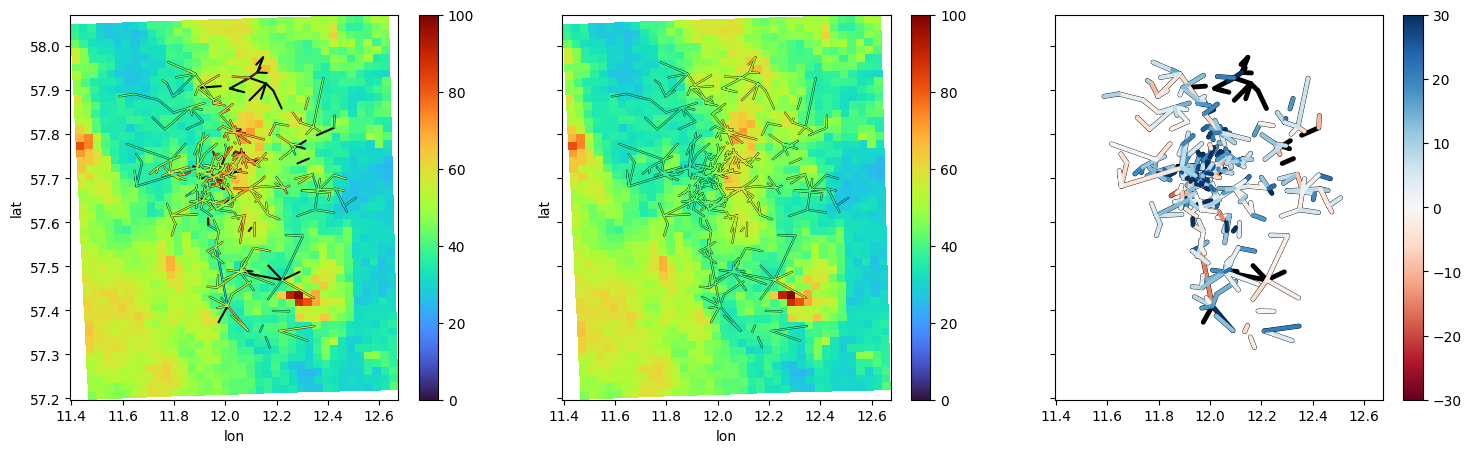

In [6]:
# Plot data on maps
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

plg.plot_map.plot_plg(
    da_grid=rad_sum,
    da_cmls=cml_sum, 
    vmin=0, 
    vmax=100,
    ax=axs[0],
    kwargs_cmls_plot={"line_width": 1},
)
plg.plot_map.plot_plg(
    da_grid=rad_sum,
    da_cmls=rad_along_cml_sum,
    kwargs_cmls_plot={"line_width": 1},
    vmin=0, 
    vmax=100,
    ax=axs[1],
)
plg.plot_map.plot_plg(
    #da_grid=rad_sum,
    da_cmls=cml_sum - rad_along_cml_sum,
    kwargs_cmls_plot={"line_width": 3, "vmin": -30, "vmax": 30, "cmap": 'RdBu'},
    vmin=0, 
    vmax=100,
    #cmap="Grays",
    ax=axs[2],
)

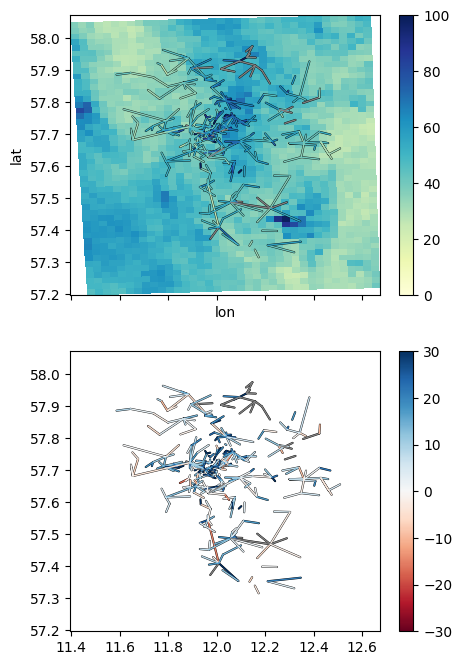

In [7]:
# plot for paper
import matplotlib as mpl
R_cmap = mpl.colormaps.get_cmap('YlGnBu')
R_cmap.set_bad(color='gray')
diff_cmap = mpl.colormaps.get_cmap('RdBu')
diff_cmap.set_bad(color='gray')

# Plot data on maps
fig, axs = plt.subplots(2, 1, figsize=(5, 8), sharex=True, sharey=True)

plg.plot_map.plot_plg(
    da_grid=rad_sum,
    da_cmls=cml_sum, 
    vmin=0, 
    vmax=100,
    ax=axs[0],
    cmap=R_cmap,
    kwargs_cmls_plot={"line_width": 1},
)

plg.plot_map.plot_plg(
    #da_grid=rad_sum,
    da_cmls=cml_sum - rad_along_cml_sum,
    kwargs_cmls_plot={"line_width": 1, "vmin": -30, "vmax": 30, "cmap": diff_cmap},
    vmin=0, 
    vmax=100,
    ax=axs[1],
);

## Apply the indicator correlation filter to detect outliers

Note that the indicator correlation filter was developed for quality control of PWS data, but we will use it here for the processed CML rainfall data to examplify the usage of tools.

In [8]:
import pypwsqc.indicator_correlation as ic

In [9]:
# Calculate CML midpoint which is then used to treat CMLs as virtual points with coordinate x and y
ds_cmls.coords["x"] = (ds_cmls.site_0_x + ds_cmls.site_1_x) / 2
ds_cmls.coords["y"] = (ds_cmls.site_0_y + ds_cmls.site_1_y) / 2

In [10]:
# Aggregate to 15 minutes
da_gauges = 4 * ds_gauges_municp.rainfall_amount.resample(time='15min').sum()
da_cmls = (
    ds_cmls.R.isel(sublink_id=0, drop=True)
    .resample(time='15min').mean()
    .rename({'cml_id': 'id'})
) 

# Calculate indicator correlation and distance matrix
dist_mtx_ref, indcorr_mtx_ref = ic.indicator_distance_matrix(
    da_gauges,
    da_gauges,
    max_distance=30e3,
    prob=0.95,
    min_valid_overlap=6 * 24,
)

100%|██████████| 10/10 [00:00<00:00, 255.28it/s]


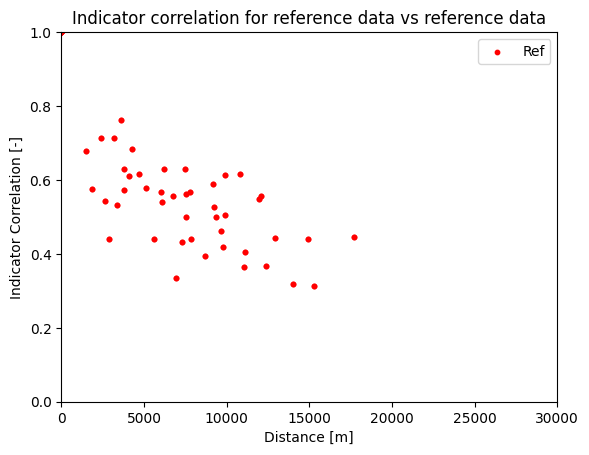

In [11]:
plt.scatter(dist_mtx_ref, indcorr_mtx_ref, color="red", s=10, label="Ref")
plt.ylim(0, 1)
plt.xlim(0, 30e3)
plt.ylabel("Indicator Correlation [-]")
plt.xlabel("Distance [m]")
plt.title("Indicator correlation for reference data vs reference data")
plt.legend();

In [12]:
# Distance and indicator correlations of reference data
dist_mtx, indcorr_mtx = ic.indicator_distance_matrix(
    da_gauges,
    da_cmls,
    max_distance=30e3,
    prob=0.95,
    min_valid_overlap=6 * 24,
)

100%|██████████| 10/10 [00:01<00:00,  7.06it/s]


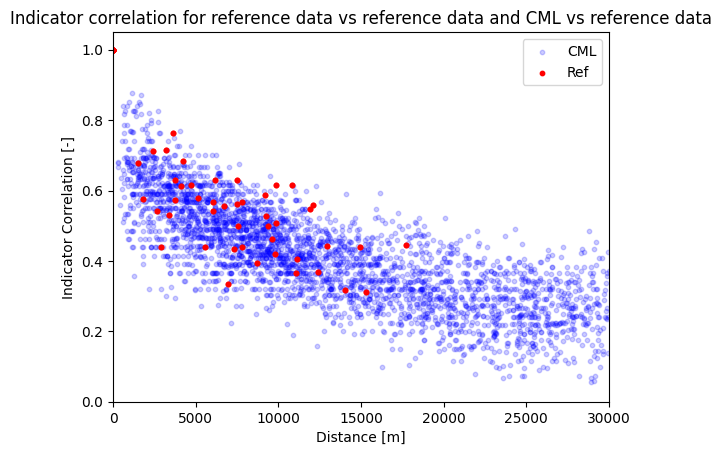

In [13]:
plt.scatter(dist_mtx, indcorr_mtx, color="b", alpha=0.2, s=10, label="CML")
plt.scatter(dist_mtx_ref, indcorr_mtx_ref, color="red", s=10, label="Ref")
plt.ylim(0, 1.05)
plt.xlim(0, 30e3)
plt.ylabel("Indicator Correlation [-]")
plt.xlabel("Distance [m]")
plt.title("Indicator correlation for reference data vs reference data and CML vs reference data")
plt.legend();

In [14]:
# Filter out CMLs with low indicator correlation
indcorr_results = ic.ic_filter(
    indicator_correlation_matrix_ref=indcorr_mtx_ref,
    distance_correlation_matrix_ref=dist_mtx_ref,
    indicator_correlation_matrix=indcorr_mtx,
    distance_matrix=dist_mtx,
    max_distance=40000,
    bin_size=1000,
    quantile_bin_ref=0.5,
    quantile_bin_pws=0.5,
    threshold=0.0,
);


/Users/chwala-c/miniforge3/envs/opensense_software_ecosystem_example/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1598: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/Users/chwala-c/miniforge3/envs/opensense_software_ecosystem_example/lib/python3.12/site-packages/pypwsqc/indicator_correlation.py:249: RuntimeWarning: invalid value encountered in scalar divide
  score = sum(indcorr_good.values * np.array(rank_sum_weights)) / normed_weights  # noqa: PD011
/Users/chwala-c/miniforge3/envs/opensense_software_ecosystem_example/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1598: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/Users/chwala-c/miniforge3/envs/opensense_software_ecosystem_example/lib/python3.12/site-packages/pypwsqc/indicator_correlation.py:249: RuntimeWarning: invalid value encountered in scalar divide
  score = sum(indcorr_good.values * np.array(rank_sum_weights)) / normed_weights  # noqa: PD

In [15]:
indcorr_results

<xarray.Dataset> Size: 65kB
Dimensions:        (id: 10, id_neighbor: 364)
Coordinates:
  * id             (id) <U6 240B 'Jarn' 'Torp' 'Bergsj' ... 'Lbom' 'Askim'
  * id_neighbor    (id_neighbor) int64 3kB 10001 10002 10003 ... 10363 10364
Data variables:
    indcorr        (id, id_neighbor) float64 29kB 0.5337 0.4188 ... 0.4081
    dist           (id, id_neighbor) float64 29kB 6.782e+03 ... 9.241e+03
    indcorr_good   (id_neighbor) bool 364B True True True ... True True True
    indcorr_score  (id_neighbor) float64 3kB 0.7323 0.3446 ... 0.2757 0.232

In [16]:
print(
    str(indcorr_results.indcorr_good.data.sum())
    + " of "
    + str(len(indcorr_results.indcorr_good))
    + " CMLs were accepted"
)

256 of 364 CMLs were accepted


In [17]:
cml_ids_bad_indcorr = indcorr_results.id_neighbor.where(
    ~indcorr_results.indcorr_good & (indcorr_results.dist.max(dim='id') < 16000), drop=True,
)
cml_ids_bad_indcorr

<xarray.DataArray 'id_neighbor' (id_neighbor: 12)> Size: 96B
array([10024., 10026., 10034., 10041., 10057., 10058., 10074., 10082.,
       10111., 10113., 10178., 10357.])
Coordinates:
  * id_neighbor  (id_neighbor) int64 96B 10024 10026 10034 ... 10113 10178 10357

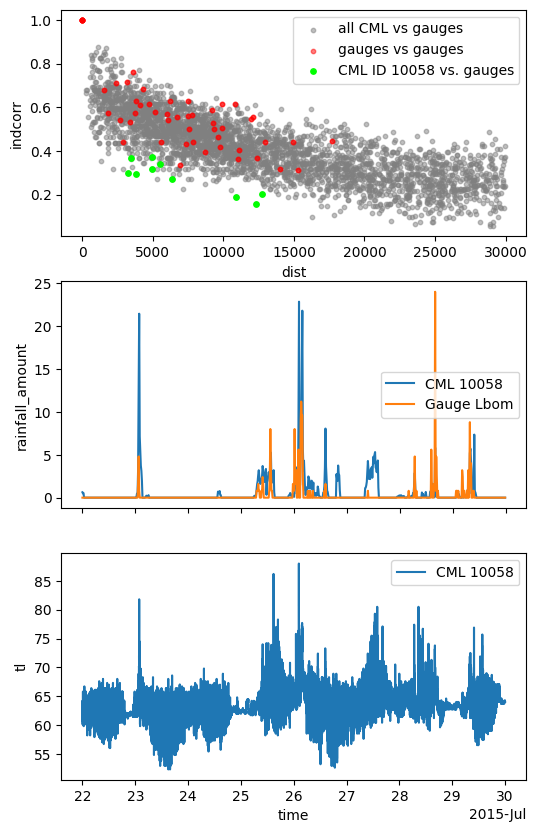

In [18]:
# Plot data of one CML with low indicator correlation
i = 5
cml_id = cml_ids_bad_indcorr[i].data

cml_id = 10058
gauge_id = 'Lbom'

fig, axs = plt.subplots(3, 1, figsize=(6, 10))
plt.sca(axs[0])
indcorr_results.plot.scatter(x="dist", y="indcorr", color="grey", alpha=0.5, s=10, label='all CML vs gauges')
plt.scatter(dist_mtx_ref, indcorr_mtx_ref, color="r", alpha=0.5, s=10, label="gauges vs gauges")
indcorr_results.sel(id_neighbor=cml_id).plot.scatter(
    x="dist", y="indcorr", color="lime", s=15, label=f'CML ID {cml_id:.0f} vs. gauges'
)
plt.legend()
plt.title('')
plt.sca(axs[1])
da_cmls.sel(id=cml_id).plot(label=f'CML {cml_id}')
da_gauges.sel(id=gauge_id).plot(label=f'Gauge {gauge_id}')
plt.legend()

plt.sca(axs[2])
ds_cmls.sel(cml_id=cml_id).isel(sublink_id=0).tl.plot(label=f'CML {cml_id}')
plt.legend()

axs[1].set_title('')
axs[2].set_title('')
axs[1].set_xlabel('')
axs[1].set_xticklabels([]);

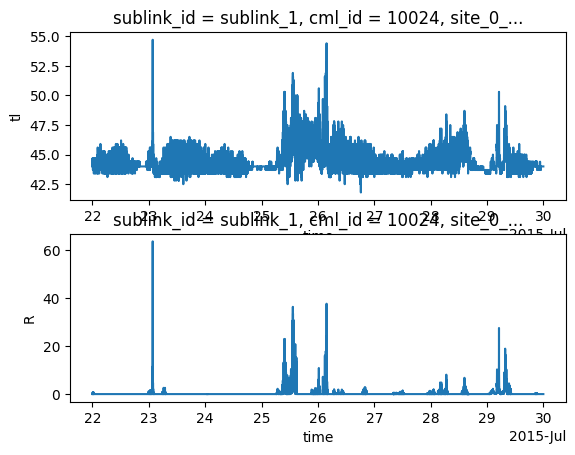

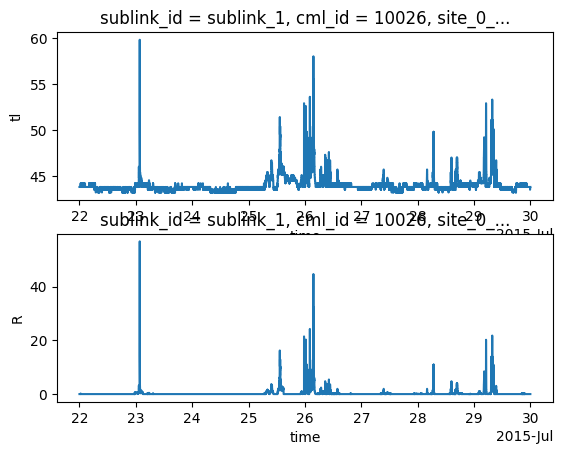

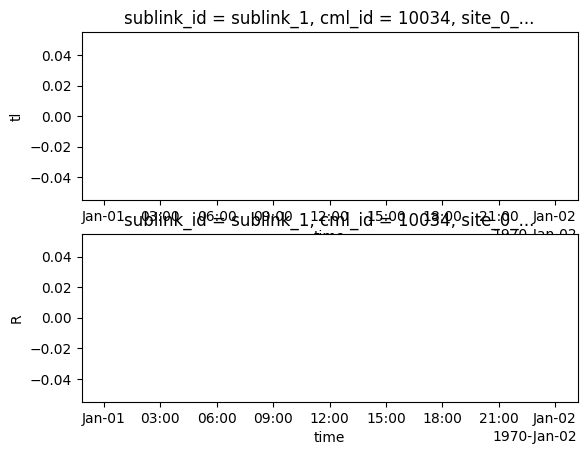

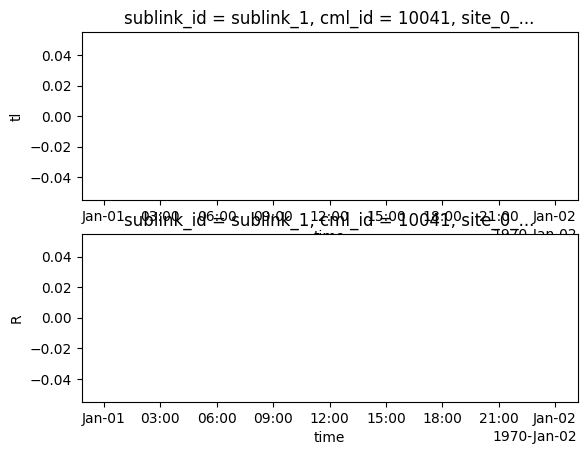

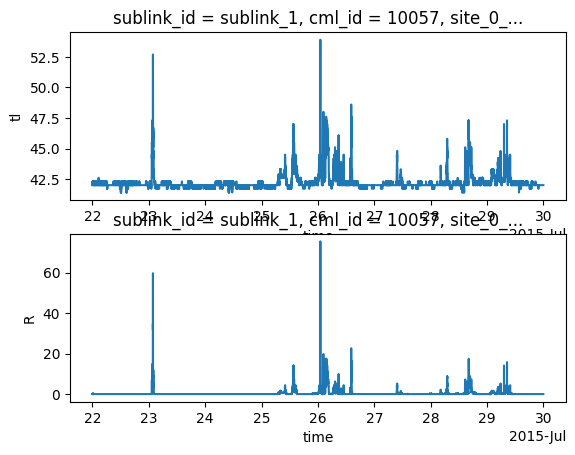

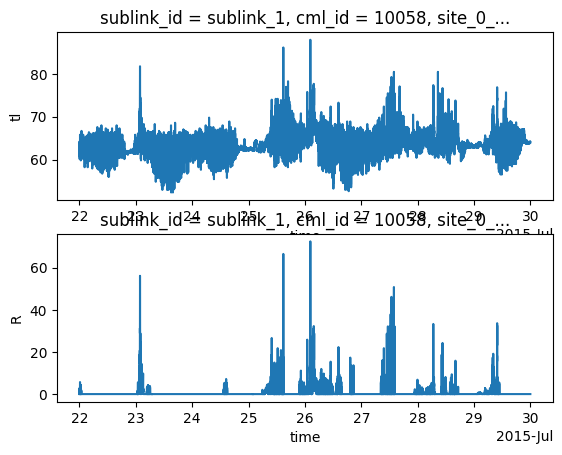

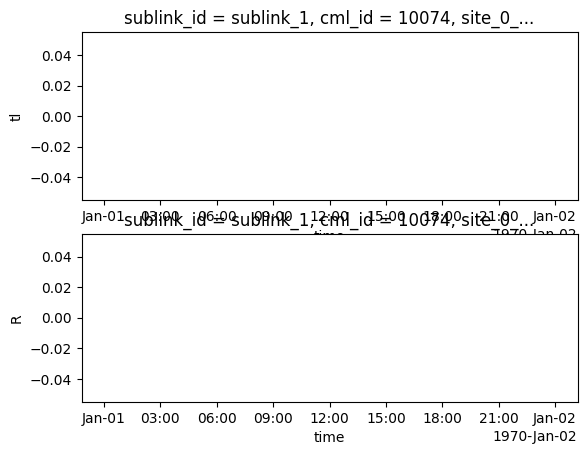

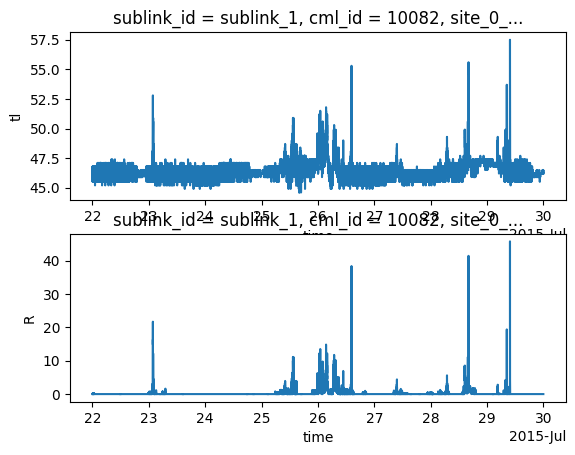

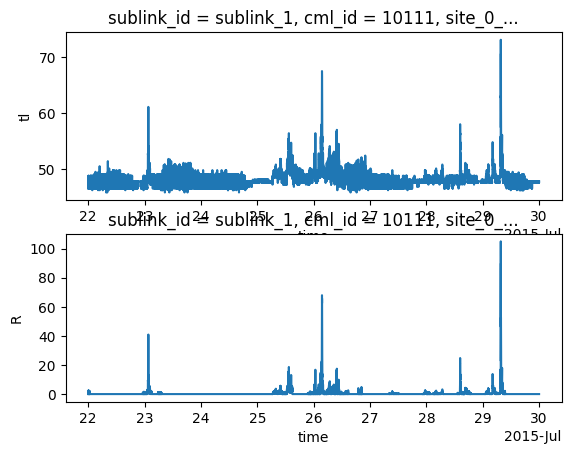

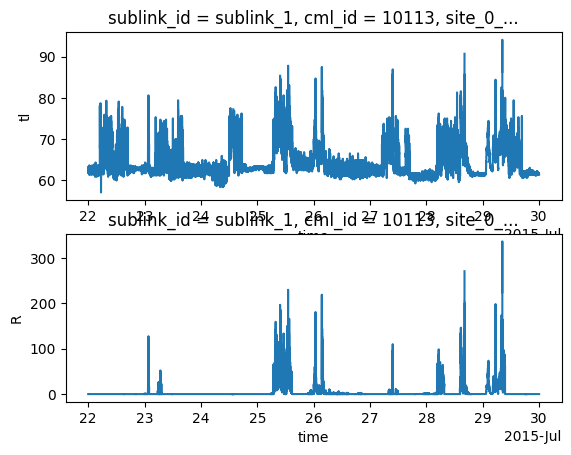

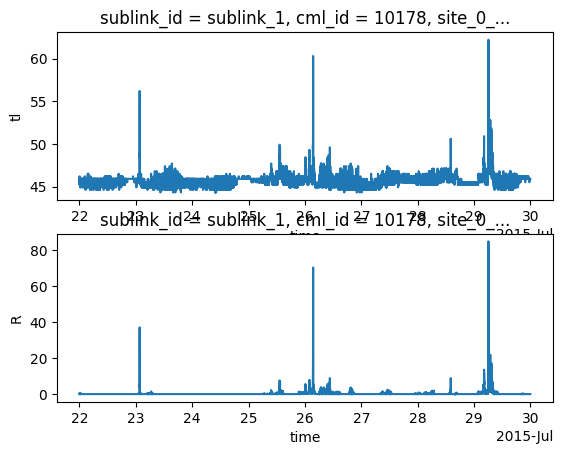

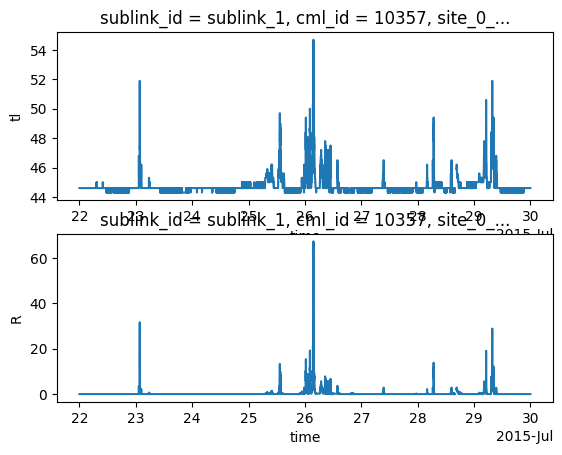

In [19]:
# Plot CMLs with low indicator correlation
for cml_id in cml_ids_bad_indcorr.values:
    fig, axs = plt.subplots(2, 1)
    ds_cmls.sel(cml_id=cml_id).isel(sublink_id=0).tl.plot(ax=axs[0])
    ds_cmls.sel(cml_id=cml_id).isel(sublink_id=0).R.plot(ax=axs[1])
    plt.show()

## Adjust radar with CMLs using mergeplg

Text(0, 0.5, '')

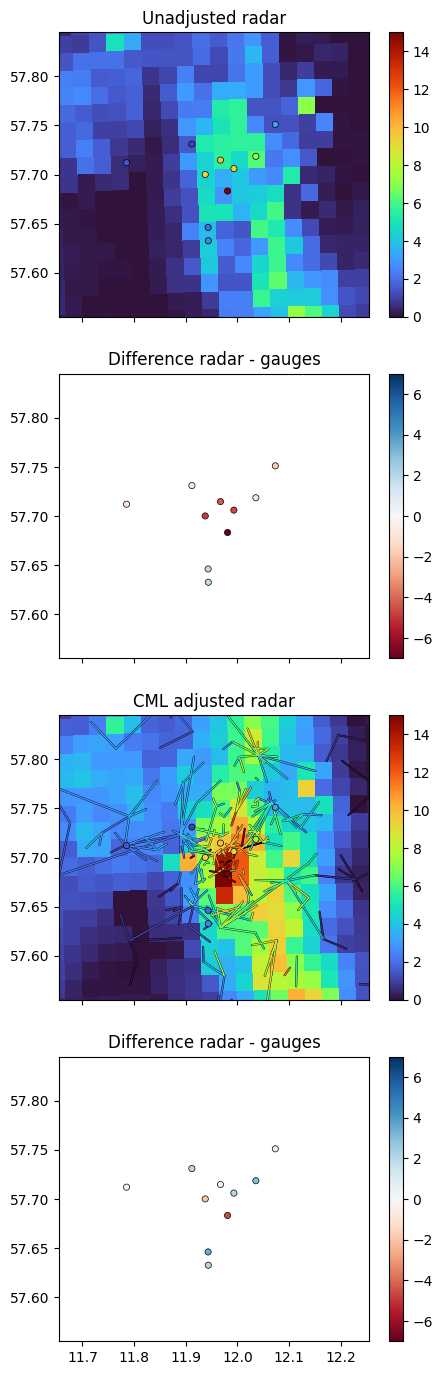

In [20]:
import mergeplg as mrg

# Set up object to get radar values at rain gauges for validation
grid_at_points = plg.spatial.GridAtPoints(
    da_gridded_data=ds_rad.R,
    da_point_data=ds_gauges_municp.rainfall_amount,
    nnear=1,
)

# Set up the merging object which internally calculates 
# and stores the CML-radar intersection weights
merge_diff_idw = mrg.merge.MergeDifferenceIDW(
    ds_rad=ds_rad.R, 
    ds_cmls=ds_cmls, 
    method='additive',
    nnear=12,
)

# Aggregate to 1h
R_radar = ds_rad.R.resample(time='1h').mean()
R_cmls = ds_cmls.isel(sublink_id=0).R.resample(time='1h').mean()
R_gauges = ds_gauges_municp.rainfall_amount.resample(time='1h').sum()

# Do adjustment for one selected timestamp
t = '2015-07-26 03:00:00'
R_grid_idw = merge_diff_idw(
    da_rad=R_radar.sel(time=t),
    da_cmls=R_cmls.sel(time=t),
)

# Get diff of radar and gauges at gauge location
R_rad_at_gauge = grid_at_points(
    da_gridded_data=R_radar.sel(time=t),
    da_point_data=R_gauges.sel(time=t),
)
R_adjusted_rad_at_gauge = grid_at_points(
    da_gridded_data=R_grid_idw,
    da_point_data=R_gauges.sel(time=t),
)

# Plotting the result
fig, axs = plt.subplots(4, 1, figsize=(5, 17), sharex=True, sharey=True)
vmin, vmax = 0, 15
vmin_diff, vmax_diff = -7, 7

plg.plot_map.plot_plg(
    da_grid=R_radar.sel(time=t),
    da_gauges=R_gauges.sel(time=t),
    vmin=vmin, 
    vmax=vmax,
    ax=axs[0],
    kwargs_cmls_plot={"line_width": 1},
)
plg.plot_map.plot_plg(
    #da_grid=R_radar.sel(time=t),
    da_gauges=R_rad_at_gauge - R_gauges.sel(time=t),
    vmin=vmin,
    vmax=vmax,
    cmap='Grays',
    ax=axs[1],
    kwargs_gauges_plot={'cmap': 'RdBu', 'vmin': vmin_diff, 'vmax': vmax_diff},
)
plg.plot_map.plot_plg(
    da_grid=R_grid_idw,
    da_cmls=R_cmls.sel(time=t),
    da_gauges=R_gauges.sel(time=t),
    kwargs_cmls_plot={"line_width": 1},
    vmin=vmin, 
    vmax=vmax,
    ax=axs[2],
)
plg.plot_map.plot_plg(
    #da_grid=R_grid_idw,
    da_gauges=R_adjusted_rad_at_gauge - R_gauges.sel(time=t),
    vmin=vmin, 
    vmax=vmax,
    cmap='Grays',
    ax=axs[3],
    kwargs_gauges_plot={'cmap': 'RdBu', 'vmin': vmin_diff, 'vmax': vmax_diff},
);

axs[0].set_title('Unadjusted radar')
axs[1].set_title('Difference radar - gauges')
axs[2].set_title('CML adjusted radar')
axs[3].set_title('Difference radar - gauges')
axs[0].set_xlim(11.655, 12.255)
axs[0].set_ylim(57.555, 57.845)
axs[0].set_xlabel('')
axs[0].set_ylabel('')
axs[2].set_xlabel('')
axs[2].set_ylabel('')